In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
features_df = pd.read_csv("../data/final/nifty_features_with_regime_5min.csv", low_memory=False)
strategy_df = pd.read_csv("../data/final/nifty_baseline_strategy_5min.csv", low_memory=False)

features_df["timestamp"] = pd.to_datetime(features_df["timestamp"])
strategy_df["timestamp"] = pd.to_datetime(strategy_df["timestamp"])

features_df = features_df.sort_values("timestamp").reset_index(drop=True)
strategy_df = strategy_df.sort_values("timestamp").reset_index(drop=True)

In [4]:
trades = []

position = 0
entry_price = None
entry_time = None

for i in range(1, len(strategy_df)):
    prev_pos = strategy_df.loc[i-1, "position"]
    curr_pos = strategy_df.loc[i, "position"]

    price = strategy_df.loc[i, "close"]

    # ENTRY
    if prev_pos == 0 and curr_pos != 0:
        position = curr_pos
        entry_price = price
        entry_time = strategy_df.loc[i, "timestamp"]

    # EXIT
    elif prev_pos != 0 and curr_pos == 0:
        exit_price = price
        exit_time = strategy_df.loc[i, "timestamp"]

        pnl = (exit_price - entry_price) * position

        trades.append({
            "entry_time": entry_time,
            "exit_time": exit_time,
            "position": position,
            "pnl": pnl,
            "target": int(pnl > 0)
        })

        position = 0

In [5]:
trades_df = pd.DataFrame(trades)

trades_df["target"].value_counts()

target
0    138
1    130
Name: count, dtype: int64

In [6]:
ml_df = trades_df.merge(
    features_df,
    left_on="entry_time",
    right_on="timestamp",
    how="left"
)

In [7]:
features = [
    "ema_5", "ema_15", "ema_diff",
    "avg_iv", "iv_spread", "pcr_oi",
    "delta_ce", "gamma_ce", "vega_ce",
    "futures_basis",
    "market_regime"
]

In [9]:
ml_df["ema_diff"] = ml_df["ema_5"] - ml_df["ema_15"]

In [10]:
ml_df = ml_df.dropna(subset=features + ["target"]).reset_index(drop=True)

X = ml_df[features]
y = ml_df["target"]

X.shape, y.value_counts()

((245739, 11),
 target
 0    126038
 1    119701
 Name: count, dtype: int64)

In [11]:
# No leakage
ml_df["entry_time"].nunique() == trades_df.shape[0]

False

In [12]:
# Balanced enough
y.value_counts(normalize=True)

target
0    0.512894
1    0.487106
Name: proportion, dtype: float64

In [13]:
# Feature validity
X.isna().sum().sum()

0

In [16]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

auc_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)
    probs = xgb_model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, probs)
    auc_scores.append(auc)

    print(f"Fold {fold} AUC: {auc:.4f}")

print("Mean AUC:", sum(auc_scores) / len(auc_scores))

Fold 0 AUC: 0.4768
Fold 1 AUC: 0.5260
Fold 2 AUC: 0.6068
Mean AUC: 0.5365501631752866


# Model B: LSTM

In [17]:
lstm_features = [
    "ema_5", "ema_15", "ema_diff",
    "avg_iv", "iv_spread", "pcr_oi",
    "delta_ce", "gamma_ce", "vega_ce",
    "futures_basis",
    "market_regime"
]

SEQ_LEN = 10

In [22]:
df = pd.read_csv("../data/final/nifty_features_with_regime_5min.csv", low_memory=False)

In [23]:
df["ema_diff"] = df["ema_5"] - df["ema_15"]

In [24]:
df = df.dropna(subset=lstm_features).reset_index(drop=True)

In [25]:
X_full = df[lstm_features].values

X_lstm_full = []
lstm_index = []

for i in range(SEQ_LEN, len(X_full)):
    X_lstm_full.append(X_full[i-SEQ_LEN:i])
    lstm_index.append(df.index[i])

X_lstm_full = np.array(X_lstm_full)

X_lstm_full.shape

(225564, 10, 11)

In [27]:
X_lstm_full.shape

(225564, 10, 11)

In [32]:
SEQ_LEN = 10
N_FEATURES = X_lstm_full.shape[2]  # should be 11

lstm_model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, N_FEATURES)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

lstm_model.summary()


C:\Users\besan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          19,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Align y for sequences
y_lstm = y.iloc[SEQ_LEN:].values

lstm_model.fit(
    X_lstm_full,
    y_lstm,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 98s 15ms/step - AUC: 0.5005 - loss: 0.6942 - val_AUC: 0.4955 - val_loss: 0.6957
Epoch 2/5
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 79s 14ms/step - AUC: 0.4991 - loss: 0.6932 - val_AUC: 0.4997 - val_loss: 0.6971
Epoch 3/5
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 80s 14ms/step - AUC: 0.5004 - loss: 0.6931 - val_AUC: 0.4997 - val_loss: 0.6966
Epoch 4/5
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 91s 16ms/step - AUC: 0.5004 - loss: 0.6931 - val_AUC: 0.4998 - val_loss: 0.6976
Epoch 5/5
5640/5640 ━━━━━━━━━━━━━━━━━━━━ 112s 20ms/step - AUC: 0.4993 - loss: 0.6931 - val_AUC: 0.4999 - val_loss: 0.6964


In [34]:
lstm_prob = lstm_model.predict(X_lstm_full).ravel()
lstm_prob.shape

7049/7049 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step


(225564,)

# Part 5.3: ML-Enhanced Backtest

In [35]:
ml_df["xgb_prob"] = xgb_model.predict_proba(X)[:, 1]

In [37]:
ml_df_lstm = ml_df.iloc[-len(lstm_prob):].reset_index(drop=True)

In [38]:
ml_df_lstm["lstm_prob"] = lstm_prob

In [39]:
ml_df_lstm["xgb_prob"] = ml_df_lstm["xgb_prob"].values

In [40]:
len(ml_df_lstm), len(lstm_prob)

(225564, 225564)

In [41]:
baseline_trades = ml_df_lstm.copy()
xgb_trades = ml_df_lstm[ml_df_lstm["xgb_prob"] > 0.5]
lstm_trades = ml_df_lstm[ml_df_lstm["lstm_prob"] > 0.5]

In [43]:
def compute_metrics(df, pnl_col="pnl"):
    total_trades = len(df)
    win_rate = (df[pnl_col] > 0).mean() * 100
    total_pnl = df[pnl_col].sum()
    avg_pnl = df[pnl_col].mean()
    
    cum_pnl = df[pnl_col].cumsum()
    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max
    max_dd = drawdown.min()
    
    sharpe = (
        df[pnl_col].mean() / df[pnl_col].std()
        if df[pnl_col].std() != 0 else 0
    )
    
    return {
        "Total Trades": total_trades,
        "Win Rate (%)": round(win_rate, 2),
        "Total PnL": round(total_pnl, 2),
        "Avg PnL / Trade": round(avg_pnl, 2),
        "Max Drawdown": round(max_dd, 2),
        "Sharpe Ratio": round(sharpe, 2)
    }

In [46]:
comparison = pd.DataFrame.from_dict(
    {
        "Baseline": compute_metrics(baseline_trades),
        "XGBoost": compute_metrics(xgb_trades),
        "LSTM": compute_metrics(lstm_trades)
    },
    orient="index"
)

comparison

,Total Trades,Win Rate (%),Total PnL,Avg PnL / Trade,Max Drawdown,Sharpe Ratio
Baseline,225564,47.81,-1232049.2,-5.46,-2692559.8,-0.05
XGBoost,134185,60.61,2673029.3,19.92,-1063401.1,0.18
LSTM,225564,47.81,-1232049.2,-5.46,-2692559.8,-0.05


In [57]:
def strategy_metrics(trades, name):
    total_return = trades["pnl"].sum()
    win_rate = (trades["pnl"] > 0).mean()
    profit_factor = (
        trades.loc[trades["pnl"] > 0, "pnl"].sum() /
        abs(trades.loc[trades["pnl"] < 0, "pnl"].sum())
    )

    return {
        "Strategy": name,
        "Trades": len(trades),
        "Total Return": total_return,
        "Win Rate": win_rate,
        "Profit Factor": profit_factor
    }

results = pd.DataFrame([
    strategy_metrics(baseline_trades, "Baseline"),
    strategy_metrics(xgb_trades, "XGBoost Filtered"),
    strategy_metrics(lstm_trades, "LSTM Filtered")
])

results

,Strategy,Trades,Total Return,Win Rate,Profit Factor
0,Baseline,225564,-1232049.2,0.478117,0.888992
1,XGBoost Filtered,134185,2673029.3,0.606148,1.595526
2,LSTM Filtered,225564,-1232049.2,0.478117,0.888992


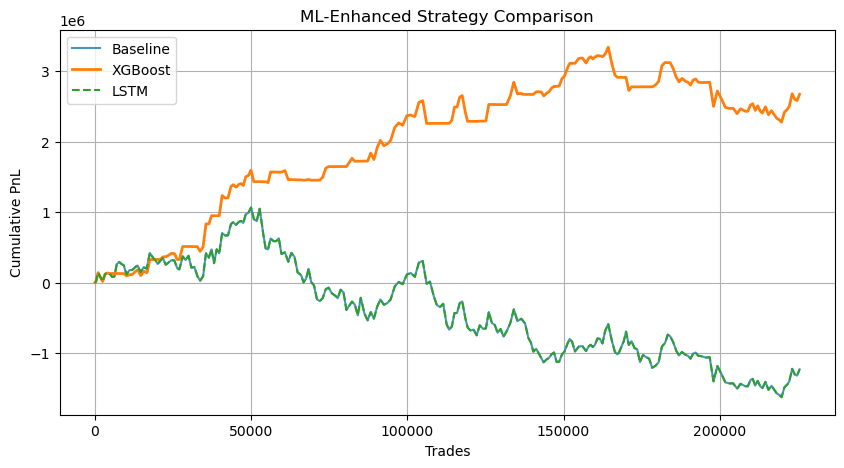

In [58]:
plt.figure(figsize=(10,5))

plt.plot(baseline_trades["pnl"].cumsum(), label="Baseline", alpha=0.8)
plt.plot(xgb_trades["pnl"].cumsum(), label="XGBoost", linewidth=2)
plt.plot(lstm_trades["pnl"].cumsum(), label="LSTM", linestyle="--")

plt.title("ML-Enhanced Strategy Comparison")
plt.xlabel("Trades")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)
plt.show()

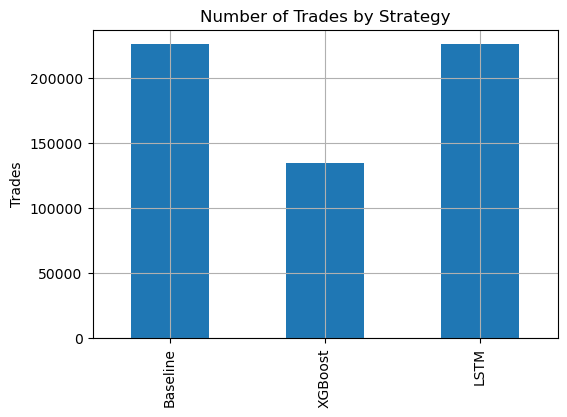

In [51]:
trade_counts = pd.Series({
    "Baseline": len(baseline_trades),
    "XGBoost": len(xgb_trades),
    "LSTM": len(lstm_trades)
})

trade_counts.plot(
    kind="bar",
    title="Number of Trades by Strategy",
    figsize=(6, 4),
    grid=True
)

plt.ylabel("Trades")
plt.show()

In [53]:
print("Baseline trades:", len(baseline_trades))
print("Has xgb_prob:", "xgb_prob" in baseline_trades.columns)
print("Has lstm_prob:", "lstm_prob" in baseline_trades.columns)

baseline_trades[["xgb_prob", "lstm_prob"]].describe()

Baseline trades: 225564
Has xgb_prob: True
Has lstm_prob: True


,xgb_prob,lstm_prob
count,225564.000000,225564.000000
mean,0.516983,0.508316
std,0.244798,0.000839
min,0.002509,0.508295
25%,0.368509,0.508295
50%,0.532813,0.508295
75%,0.643867,0.508295
max,0.987762,0.556607


In [54]:
xgb_trades = baseline_trades[
    baseline_trades["xgb_prob"] > 0.5
].copy()

lstm_trades = baseline_trades[
    baseline_trades["lstm_prob"] > 0.5
].copy()

In [55]:
print("Baseline trades:", len(baseline_trades))
print("XGB trades:", len(xgb_trades))
print("LSTM trades:", len(lstm_trades))

Baseline trades: 225564
XGB trades: 134185
LSTM trades: 225564


In [56]:
baseline_trades["lstm_prob"].value_counts(bins=5)

(0.507, 0.518]    225368
(0.528, 0.537]       138
(0.537, 0.547]        32
(0.518, 0.528]        22
(0.547, 0.557]         4
Name: count, dtype: int64